<a href="https://colab.research.google.com/github/imankit23/Comparative-analysis-between-Neuro-symbolic-and-Deep-Learning-IDS/blob/main/LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from keras.utils import to_categorical
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten
from keras.optimizers import SGD
import os
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
df = pd.read_csv("/content/friday.csv") #CSE-CIC-IDS 2017 (friday )
df

,id,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,...,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,ICMP Code,ICMP Type,Total TCP Flow Time,Label,Attempted Category
0,1,192.168.10.50-192.168.10.3-56108-3268-6,192.168.10.50,56108,192.168.10.3,3268,6,2017-07-07 11:59:50.315195,112740690,32,...,343,1.610540e+07,4.988048e+05,16399772,15375229,-1,-1,112740690,BENIGN,-1
1,2,192.168.10.50-192.168.10.3-42144-389-6,192.168.10.50,42144,192.168.10.3,389,6,2017-07-07 11:59:50.316273,112740560,32,...,285,1.610543e+07,4.987937e+05,16399782,15375263,-1,-1,112740560,BENIGN,-1
2,3,8.6.0.1-8.0.6.4-0-0-0,8.6.0.1,0,8.0.6.4,0,0,2017-07-07 12:00:31.388567,113757377,545,...,19,1.221036e+07,6.935824e+06,20757030,5504997,-1,-1,0,BENIGN,-1
3,4,192.168.10.25-224.0.0.251-5353-5353-17,192.168.10.25,5353,224.0.0.251,5353,17,2017-07-07 12:00:42.903850,91997219,388,...,16,1.319764e+07,5.826905e+06,19776791,5817470,-1,-1,0,BENIGN,-1
4,5,192.168.10.25-17.253.14.125-123-123-17,192.168.10.25,123,17.253.14.125,123,17,2017-07-07 12:00:42.430758,66966070,6,...,1968172,6.497443e+07,0.000000e+00,64974431,64974431,-1,-1,0,BENIGN,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
547552,547553,172.16.0.1-192.168.10.50-64318-2222-6,172.16.0.1,64318,192.168.10.50,2222,6,2017-07-07 18:09:11.499555,64,1,...,0,0.000000e+00,0.000000e+00,0,0,-1,-1,64,Portscan,-1
547553,547554,172.16.0.1-192.168.10.50-33248-9040-6,172.16.0.1,33248,192.168.10.50,9040,6,2017-07-07 17:54:38.857717,76,1,...,0,0.000000e+00,0.000000e+00,0,0,-1,-1,76,Portscan,-1
547554,547555,172.16.0.1-192.168.10.50-44033-1272-6,172.16.0.1,44033,192.168.10.50,1272,6,2017-07-07 17:52:03.285040,81,1,...,0,0.000000e+00,0.000000e+00,0,0,-1,-1,81,Portscan,-1
547555,547556,192.168.10.16-192.168.10.3-64748-53-17,192.168.10.16,64748,192.168.10.3,53,17,2017-07-07 18:33:45.701233,297,2,...,0,0.000000e+00,0.000000e+00,0,0,-1,-1,0,BENIGN,-1


In [ ]:
print(df.head())
print(df['Label'].value_counts())


   id                                  Flow ID         Src IP  Src Port  \
0   1  192.168.10.50-192.168.10.3-56108-3268-6  192.168.10.50     56108   
1   2   192.168.10.50-192.168.10.3-42144-389-6  192.168.10.50     42144   
2   3                    8.6.0.1-8.0.6.4-0-0-0        8.6.0.1         0   
3   4   192.168.10.25-224.0.0.251-5353-5353-17  192.168.10.25      5353   
4   5   192.168.10.25-17.253.14.125-123-123-17  192.168.10.25       123   

          Dst IP  Dst Port  Protocol                   Timestamp  \
0   192.168.10.3      3268         6  2017-07-07 11:59:50.315195   
1   192.168.10.3       389         6  2017-07-07 11:59:50.316273   
2        8.0.6.4         0         0  2017-07-07 12:00:31.388567   
3    224.0.0.251      5353        17  2017-07-07 12:00:42.903850   
4  17.253.14.125       123        17  2017-07-07 12:00:42.430758   

   Flow Duration  Total Fwd Packet  ...  Active Min     Idle Mean  \
0      112740690                32  ...         343  1.610540e+07   
1 

In [ ]:
cols = df.columns
cols = cols.map(lambda x: x.replace(' ', '_') )
df.columns = cols
print(df.head())

   id                                  Flow_ID         Src_IP  Src_Port  \
0   1  192.168.10.50-192.168.10.3-56108-3268-6  192.168.10.50     56108   
1   2   192.168.10.50-192.168.10.3-42144-389-6  192.168.10.50     42144   
2   3                    8.6.0.1-8.0.6.4-0-0-0        8.6.0.1         0   
3   4   192.168.10.25-224.0.0.251-5353-5353-17  192.168.10.25      5353   
4   5   192.168.10.25-17.253.14.125-123-123-17  192.168.10.25       123   

          Dst_IP  Dst_Port  Protocol                   Timestamp  \
0   192.168.10.3      3268         6  2017-07-07 11:59:50.315195   
1   192.168.10.3       389         6  2017-07-07 11:59:50.316273   
2        8.0.6.4         0         0  2017-07-07 12:00:31.388567   
3    224.0.0.251      5353        17  2017-07-07 12:00:42.903850   
4  17.253.14.125       123        17  2017-07-07 12:00:42.430758   

   Flow_Duration  Total_Fwd_Packet  ...  Active_Min     Idle_Mean  \
0      112740690                32  ...         343  1.610540e+07   
1 

In [ ]:
#replace infinit number
df=df.replace([np.inf, -np.inf], np.nan).dropna(axis=1)

#drop null
df.dropna(how = 'all')

,id,Flow_ID,Src_IP,Src_Port,Dst_IP,Dst_Port,Protocol,Timestamp,Flow_Duration,Total_Fwd_Packet,...,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min,ICMP_Code,ICMP_Type,Total_TCP_Flow_Time,Label,Attempted_Category
0,1,192.168.10.50-192.168.10.3-56108-3268-6,192.168.10.50,56108,192.168.10.3,3268,6,2017-07-07 11:59:50.315195,112740690,32,...,343,1.610540e+07,4.988048e+05,16399772,15375229,-1,-1,112740690,BENIGN,-1
1,2,192.168.10.50-192.168.10.3-42144-389-6,192.168.10.50,42144,192.168.10.3,389,6,2017-07-07 11:59:50.316273,112740560,32,...,285,1.610543e+07,4.987937e+05,16399782,15375263,-1,-1,112740560,BENIGN,-1
2,3,8.6.0.1-8.0.6.4-0-0-0,8.6.0.1,0,8.0.6.4,0,0,2017-07-07 12:00:31.388567,113757377,545,...,19,1.221036e+07,6.935824e+06,20757030,5504997,-1,-1,0,BENIGN,-1
3,4,192.168.10.25-224.0.0.251-5353-5353-17,192.168.10.25,5353,224.0.0.251,5353,17,2017-07-07 12:00:42.903850,91997219,388,...,16,1.319764e+07,5.826905e+06,19776791,5817470,-1,-1,0,BENIGN,-1
4,5,192.168.10.25-17.253.14.125-123-123-17,192.168.10.25,123,17.253.14.125,123,17,2017-07-07 12:00:42.430758,66966070,6,...,1968172,6.497443e+07,0.000000e+00,64974431,64974431,-1,-1,0,BENIGN,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
547552,547553,172.16.0.1-192.168.10.50-64318-2222-6,172.16.0.1,64318,192.168.10.50,2222,6,2017-07-07 18:09:11.499555,64,1,...,0,0.000000e+00,0.000000e+00,0,0,-1,-1,64,Portscan,-1
547553,547554,172.16.0.1-192.168.10.50-33248-9040-6,172.16.0.1,33248,192.168.10.50,9040,6,2017-07-07 17:54:38.857717,76,1,...,0,0.000000e+00,0.000000e+00,0,0,-1,-1,76,Portscan,-1
547554,547555,172.16.0.1-192.168.10.50-44033-1272-6,172.16.0.1,44033,192.168.10.50,1272,6,2017-07-07 17:52:03.285040,81,1,...,0,0.000000e+00,0.000000e+00,0,0,-1,-1,81,Portscan,-1
547555,547556,192.168.10.16-192.168.10.3-64748-53-17,192.168.10.16,64748,192.168.10.3,53,17,2017-07-07 18:33:45.701233,297,2,...,0,0.000000e+00,0.000000e+00,0,0,-1,-1,0,BENIGN,-1


In [ ]:
print('Data type of each column of Dataframe :')
df.info(verbose=True)

Data type of each column of Dataframe :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 547557 entries, 0 to 547556
Data columns (total 91 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   id                          547557 non-null  int64  
 1   Flow_ID                     547557 non-null  object 
 2   Src_IP                      547557 non-null  object 
 3   Src_Port                    547557 non-null  int64  
 4   Dst_IP                      547557 non-null  object 
 5   Dst_Port                    547557 non-null  int64  
 6   Protocol                    547557 non-null  int64  
 7   Timestamp                   547557 non-null  object 
 8   Flow_Duration               547557 non-null  int64  
 9   Total_Fwd_Packet            547557 non-null  int64  
 10  Total_Bwd_packets           547557 non-null  int64  
 11  Total_Length_of_Fwd_Packet  547557 non-null  int64  
 12  Total_Length_of_Bwd_Packet  5475

In [ ]:
df = df.drop(columns=['Timestamp', 'Flow_ID', 'Src_IP', 'Dst_IP'])
print('Timestamp, ', 'Flow_ID, ', 'Src_IP, ', 'Dst_IP, ', "columns are dropped")

Timestamp,  Flow_ID,  Src_IP,  Dst_IP,  columns are dropped


In [ ]:

print(df['Label'].value_counts())

Label
BENIGN                288544
Portscan              159066
DDoS                   95144
Botnet - Attempted      4067
Botnet                   736
Name: count, dtype: int64


In [ ]:
df.Label[df.Label=='BENIGN'] = 0
df.Label[df.Label =='Portscan'] = 1
df.Label[df.Label =='DDoS'] = 1
df.Label[df.Label =='Botnet - Attempted'] = 1
df.Label[df.Label =='Botnet'] = 1
df["Label"].astype('Int64')
print(df['Label'].value_counts())

/tmp/ipython-input-3053153228.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df.Label[df.Label=='BENIGN'] = 0
/tmp/ipython-input-3053153228.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

Label
0    288544
1    259013
Name: count, dtype: int64


In [ ]:
# Count the number of rows in each class
ddos_count = df[df['Label'] == 1].shape[0]
benign_count = df[df['Label'] == 0].shape[0]

# Randomly sample the benign rows to reduce their count
df_benign = df[df['Label'] == 0].sample(n=ddos_count, random_state=42)

# Combine the DDoS and sampled benign rows into a new dataframe
df_reduced = pd.concat([df[df['Label'] == 1], df_benign])

# Shuffle the rows in the new dataframe
df_reduced = df_reduced.sample(frac=1, random_state=42)

df = df_reduced
df["Label"].astype('float')
print(df['Label'].value_counts())

Label
0    259013
1    259013
Name: count, dtype: int64


In [ ]:
bening_df = df[df['Label']==0]
malignant_df = df[df['Label']==1]

<Axes: xlabel='Flow_Duration', ylabel='Total_Fwd_Packet'>

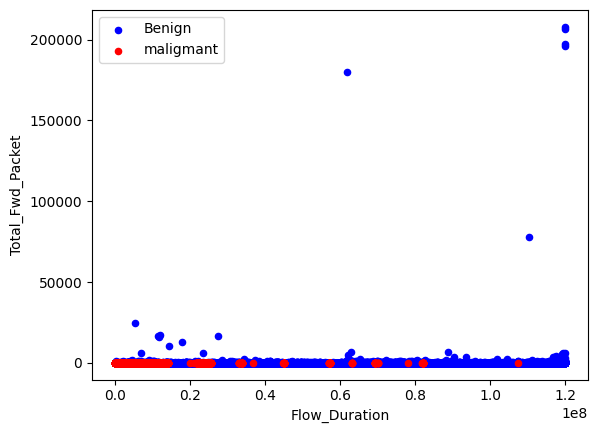

In [ ]:
axes = bening_df.plot(kind='scatter', x='Flow_Duration', y = 'Total_Fwd_Packet', color='blue', label='Benign')
malignant_df.plot(kind='scatter', x='Flow_Duration', y = 'Total_Fwd_Packet', color='red', label='maligmant', ax=axes)

In [ ]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns
print(cat_cols)

cat_cols = df.select_dtypes(include='object').columns
print(cat_cols)

print('Data type of each column of Dataframe :')
df.info(verbose=True)

Index(['Label'], dtype='object')
Index(['Label'], dtype='object')
Data type of each column of Dataframe :
<class 'pandas.core.frame.DataFrame'>
Index: 518026 entries, 267811 to 299649
Data columns (total 87 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   id                          518026 non-null  int64  
 1   Src_Port                    518026 non-null  int64  
 2   Dst_Port                    518026 non-null  int64  
 3   Protocol                    518026 non-null  int64  
 4   Flow_Duration               518026 non-null  int64  
 5   Total_Fwd_Packet            518026 non-null  int64  
 6   Total_Bwd_packets           518026 non-null  int64  
 7   Total_Length_of_Fwd_Packet  518026 non-null  int64  
 8   Total_Length_of_Bwd_Packet  518026 non-null  int64  
 9   Fwd_Packet_Length_Max       518026 non-null  int64  
 10  Fwd_Packet_Length_Min       518026 non-null  int64  
 11  Fwd_Packet_Length_Mean  

In [ ]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Select a subset of the data for training
num_data = 15000 # can change between 500 and 1152382
train_df = df.iloc[:num_data].copy() # Use .iloc to avoid a SettingWithCopyWarning


print('Data type of each column of Dataframe :')
train_df.info(verbose=True)

Data type of each column of Dataframe :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 87 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          15000 non-null  int64  
 1   Src_Port                    15000 non-null  int64  
 2   Dst_Port                    15000 non-null  int64  
 3   Protocol                    15000 non-null  int64  
 4   Flow_Duration               15000 non-null  int64  
 5   Total_Fwd_Packet            15000 non-null  int64  
 6   Total_Bwd_packets           15000 non-null  int64  
 7   Total_Length_of_Fwd_Packet  15000 non-null  int64  
 8   Total_Length_of_Bwd_Packet  15000 non-null  int64  
 9   Fwd_Packet_Length_Max       15000 non-null  int64  
 10  Fwd_Packet_Length_Min       15000 non-null  int64  
 11  Fwd_Packet_Length_Mean      15000 non-null  float64
 12  Fwd_Packet_Length_Std       15000 non-null  floa

In [ ]:
train_size = int(0.7 * len(train_df))
val_size = int(0.15 * len(train_df))
test_size = len(train_df) - train_size - val_size
train_data = train_df.iloc[:train_size, :]
val_data = train_df.iloc[train_size:train_size+val_size, :]
test_data = train_df.iloc[train_size+val_size:, :]

In [ ]:
# Define sequence length and overlap
seq_length = 10 # Sequence length
seq_overlap = 5 # Overlap between sequences

# Function to generate sequences
def generate_sequences(data):
    seqs = []
    for i in range(0, len(data) - seq_length + 1, seq_overlap):
        seqs.append(data.iloc[i:i+seq_length, :])
    return seqs

# Generate sequences for train, validation, and test sets
train_seqs = generate_sequences(train_data)
val_seqs = generate_sequences(val_data)
test_seqs = generate_sequences(test_data)

In [ ]:
# Function to pad sequences
def pad_sequences(seqs):
    padded_seqs = []
    for seq in seqs:
        if len(seq) < seq_length:
            padded_seq = np.concatenate((seq, np.zeros((seq_length-len(seq), len(df.columns)))), axis=0)
        else:
            padded_seq = seq
        padded_seqs.append(padded_seq)
    return np.array(padded_seqs)

# Pad sequences for train, validation, and test sets
train_seqs = pad_sequences(train_seqs)
val_seqs = pad_sequences(val_seqs)
test_seqs = pad_sequences(test_seqs)

In [ ]:
# Reshape input
train_X = np.reshape(train_seqs, (train_seqs.shape[0], train_seqs.shape[1], len(train_df.columns)))
val_X = np.reshape(val_seqs, (val_seqs.shape[0], val_seqs.shape[1], len(train_df.columns)))
test_X = np.reshape(test_seqs, (test_seqs.shape[0], test_seqs.shape[1], len(train_df.columns)))

In [ ]:
# Normalize data
train_X = (train_X - train_X.mean()) / train_X.std()
val_X = (val_X - train_X.mean()) / train_X.std()
test_X = (test_X - train_X.mean()) / train_X.std()

In [ ]:
# Convert labels to categorical
train_y = to_categorical(train_data["Label"].values[:train_X.shape[0]])
val_y = to_categorical(val_data["Label"].values[:val_X.shape[0]])
test_y = to_categorical(test_data["Label"].values[:test_X.shape[0]])
train_X = train_X.astype('float32')
train_y = train_y.astype('float32')
val_X = val_X.astype('float32')
val_y = val_y.astype('float32')

In [ ]:
# Import necessary libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.optimizers import SGD # Changed import for consistency
seq_length = 10 # set the sequence length
n_features = len(df.columns) # number of features in the dataset

# Define model architecture
from keras.layers import Activation

# Define model architecture with ReLU activation function
model = Sequential()
model.add(LSTM(units=64, input_shape=(seq_length, n_features), return_sequences=True))
model.add(LSTM(units=32, return_sequences=False))
model.add(Dropout(0.2))

model.add(Activation('relu'))
model.add(Dense(units=2, activation='softmax'))


# Compile model with SGD optimizer
sgd = SGD(learning_rate=0.01, momentum=0.9, nesterov=True) # Corrected argument: lr to learning_rate, removed decay
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print(train_X.shape, train_y.shape, val_X.shape, val_y.shape)
model.summary()

(2099, 10, 87) (2099, 2) (449, 10, 87) (449, 2)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 10, 64)         │        38,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,394 (200.76 KB)

 Trainable params: 51,394 (200.76 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train model
early_stop = EarlyStopping(monitor='val_loss', patience=10, verbose=1)
history = model.fit(train_X, train_y, epochs=100, batch_size=16, validation_split=0.1, callbacks=[early_stop])
history

Epoch 1/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.4802 - loss: 0.6936 - val_accuracy: 0.5190 - val_loss: 0.6952
Epoch 2/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5157 - loss: 0.6936 - val_accuracy: 0.4810 - val_loss: 0.6992
Epoch 3/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5237 - loss: 0.6915 - val_accuracy: 0.5333 - val_loss: 0.6933
Epoch 4/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5393 - loss: 0.6896 - val_accuracy: 0.4905 - val_loss: 0.6998
Epoch 5/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5220 - loss: 0.6910 - val_accuracy: 0.4571 - val_loss: 0.7057
Epoch 6/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5240 - loss: 0.6895 - val_accuracy: 0.5143 - val_loss: 0.6993
Epoch 7/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5469 - loss: 0.6877 - val_accuracy: 0.5476 - val_loss: 0.6960
Epoch 8/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5153 - loss: 0.6897 - 

<function matplotlib.pyplot.show(close=None, block=None)>

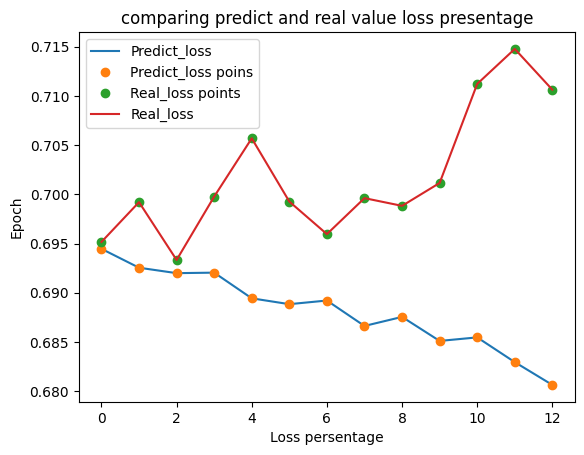

In [ ]:
#loss plot
plt.plot(history.history['loss'])
plt.plot(history.history['loss'], 'o')
plt.plot(history.history['val_loss'], 'o')
plt.plot(history.history['val_loss'])
plt.title('comparing predict and real value loss presentage')
plt.xlabel('Loss persentage')
plt.ylabel('Epoch')
plt.legend(['Predict_loss','Predict_loss poins','Real_loss points', 'Real_loss'])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

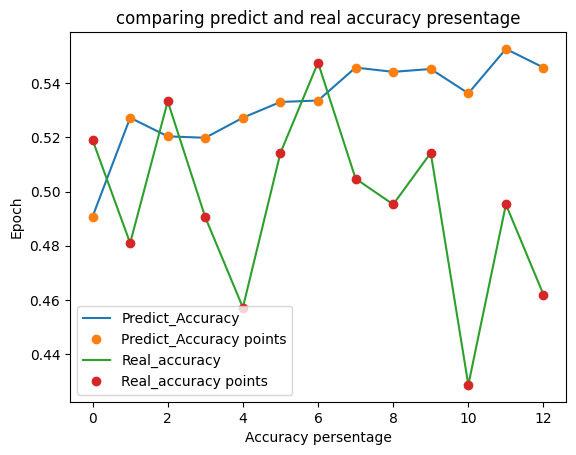

In [ ]:
#accuracy plot
plt.plot(history.history['accuracy'])
plt.plot(history.history['accuracy'],'o')
plt.plot(history.history['val_accuracy'])
plt.plot(history.history['val_accuracy'],'o')
plt.title('comparing predict and real accuracy presentage')
plt.xlabel('Accuracy persentage')
plt.ylabel('Epoch')
plt.legend(['Predict_Accuracy','Predict_Accuracy points', 'Real_accuracy','Real_accuracy points'])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

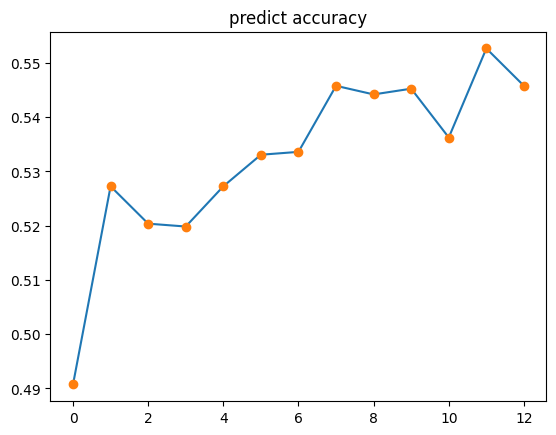

In [ ]:
#accuracy Plot
plt.plot(history.history['accuracy'])
plt.plot(history.history['accuracy'],'o')
plt.title('predict accuracy')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

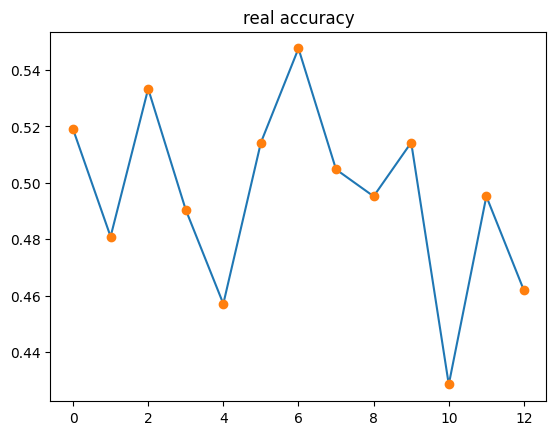

In [ ]:
#val_accuracy Plot
plt.plot(history.history['val_accuracy'])
plt.plot(history.history['val_accuracy'],'o')
plt.title('real accuracy')
plt.show

In [ ]:
# Predict on training data
y_pred_prob = model.predict(train_X)

# Convert probabilities to binary labels
y_pred = (y_pred_prob > 0.5).astype(int).reshape(-1)
y_true = train_y.reshape(-1)

66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall    = recall_score(y_true, y_pred)   # Detection Rate
f1        = f1_score(y_true, y_pred)

print(" LSTM IDS Evaluation on CICIDS-2017")
print(f"Accuracy        : {accuracy:.4f}")
print(f"Precision       : {precision:.4f}")
print(f"Recall (DR)     : {recall:.4f}")
print(f"F1-score        : {f1:.4f}")

# 4. False Positive / False Negative Analysis
# =========================
false_positive_rate = FP / (FP + TN)
false_negative_rate = FN / (FN + TP)

print(f"False Positive Rate : {false_positive_rate:.4f}")
print(f"False Negative Rate : {false_negative_rate:.4f}")

 LSTM IDS Evaluation on CICIDS-2017
Accuracy        : 0.5460
Precision       : 0.5460
Recall (DR)     : 0.5460
F1-score        : 0.5460
False Positive Rate : 0.4540
False Negative Rate : 0.4540


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_true, y_pred)
TN, FP, FN, TP = cm.ravel()

print("\n Confusion Matrix")
print(cm)

print("\n Error Analysis")
print(f"True Positives  (TP): {TP}")
print(f"True Negatives  (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")

false_positive_rate = FP / (FP + TN)
false_negative_rate = FN / (FN + TP)

print(f"False Positive Rate : {false_positive_rate:.4f}")
print(f"False Negative Rate : {false_negative_rate:.4f}")

print("\n CLASSIFICATION REPORT")
print(classification_report(y_true, y_pred, digits=4))



 Confusion Matrix
[[1146  953]
 [ 953 1146]]

 Error Analysis
True Positives  (TP): 1146
True Negatives  (TN): 1146
False Positives (FP): 953
False Negatives (FN): 953
False Positive Rate : 0.4540
False Negative Rate : 0.4540

 CLASSIFICATION REPORT
              precision    recall  f1-score   support

         0.0     0.5460    0.5460    0.5460      2099
         1.0     0.5460    0.5460    0.5460      2099

    accuracy                         0.5460      4198
   macro avg     0.5460    0.5460    0.5460      4198
weighted avg     0.5460    0.5460    0.5460      4198

